In [2]:
# ── Cell 1: Imports + save helper ─────────────────────────────────────────────
import os
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.optimize import curve_fit
import warnings

import RamanHelpers as rh

mpl.rcParams.update({
    "figure.dpi"       : 150,
    "axes.grid"        : True,
    "grid.alpha"       : 0.3,
    "axes.spines.top"  : False,
    "axes.spines.right": False,
})

SAVE_FILE = "ferrari_results.npz"

def save_results(**kwargs):
    store = dict(np.load(SAVE_FILE, allow_pickle=True)) \
            if os.path.exists(SAVE_FILE) else {}
    store.update(kwargs)
    np.savez(SAVE_FILE, **store)
    keys = list(kwargs.keys())
    print(f"  ✓ Saved {len(keys)} variable(s) → {SAVE_FILE}")
    print(f"    {keys}")

print("Imports OK")
print(f"Save file : {SAVE_FILE}")
print(f"rh        : {rh.__file__}")

Imports OK
Save file : ferrari_results.npz
rh        : /Users/egeeroglu/Desktop/RIRO/Tuesday/RamanData/RamanHelpers.py


In [3]:
# ── Cell 2: Load data from previous notebooks ──────────────────────────────────
# Pulls everything needed for Ferrari analysis from the three .npz files:
#   fit_results.npz    → single-spectrum D, G fit parameters + ratios
#   map_results.npz    → per-pixel D, G fit parameters across 400 spectra
#   calibration_results.npz → CAL_OFFSET

# ── Calibration ───────────────────────────────────────────────────────────────
if not os.path.exists("calibration_results.npz"):
    raise FileNotFoundError("Run calibration notebook first.")
cal        = np.load("calibration_results.npz", allow_pickle=True)
CAL_OFFSET = float(cal["cal_offset"])
print(f"CAL_OFFSET : {CAL_OFFSET:+.4f} cm⁻¹")

# ── Single spectrum results ───────────────────────────────────────────────────
if not os.path.exists("fit_results.npz"):
    raise FileNotFoundError("Run main analysis notebook first.")
fit = np.load("fit_results.npz", allow_pickle=True)

# Single spectrum — best representative (index idx_best)
IDX_BEST    = int(fit["idx_best"])
EL          = float(fit["EL"])             # laser energy eV
amp_D_ss    = float(fit["d_amp"])          # D amplitude
fwhm_D_ss   = float(fit["d_fwhm"])        # D FWHM
amp_G_ss    = float(fit["g_amp"])          # G amplitude
fwhm_G_ss   = float(fit["g_fwhm"])        # G FWHM
area_D_ss   = float(fit["d_area"])        # D area = amp*fwhm*π/2
area_G_ss   = float(fit["g_area"])        # G area

# Pre-computed ratios from fit_results
ratio_DG_amp_ss  = float(fit["ratio_dg_amp"])
ratio_DG_area_ss = float(fit["ratio_dg_area"])

print(f"\n── Single spectrum (idx {IDX_BEST}) ─────────────────────────────────")
print(f"  EL             : {EL} eV  (532 nm)")
print(f"  D amp / fwhm   : {amp_D_ss:.2f} / {fwhm_D_ss:.2f} cm⁻¹")
print(f"  G amp / fwhm   : {amp_G_ss:.2f} / {fwhm_G_ss:.2f} cm⁻¹")
print(f"  I(D)/I(G) amp  : {ratio_DG_amp_ss:.4f}")
print(f"  I(D)/I(G) area : {ratio_DG_area_ss:.4f}")

# ── Map results ───────────────────────────────────────────────────────────────
if not os.path.exists("map_results.npz"):
    raise FileNotFoundError("Run mapping notebook first.")
maps = np.load("map_results.npz", allow_pickle=True)

map_d_amp   = maps["map_d_amp"]
map_d_fwhm  = maps["map_d_fwhm"]
map_d_area  = maps["map_d_area"]
map_g_amp   = maps["map_g_amp"]
map_g_fwhm  = maps["map_g_fwhm"]
map_g_area  = maps["map_g_area"]

# Ratios — recompute from loaded arrays for consistency
map_ratio_dg_amp  = map_d_amp  / map_g_amp
map_ratio_dg_area = map_d_area / map_g_area

N_SPEC = len(map_d_amp)
NX, NY = 20, 20
EXTENT = [0, 83.123894, 93.966141, 0]

print(f"\n── Map data ──────────────────────────────────────────────────────────")
print(f"  N spectra      : {N_SPEC}")
valid_d = np.sum(~np.isnan(map_d_amp))
print(f"  D band fits    : {valid_d}/{N_SPEC}  ({100*valid_d/N_SPEC:.0f}%)")
print(f"  I(D)/I(G) amp  : mean={np.nanmean(map_ratio_dg_amp):.4f}  "
      f"std={np.nanstd(map_ratio_dg_amp):.4f}  "
      f"range=[{np.nanmin(map_ratio_dg_amp):.4f}, "
      f"{np.nanmax(map_ratio_dg_amp):.4f}]")

CAL_OFFSET : +1.0809 cm⁻¹

── Single spectrum (idx 134) ─────────────────────────────────
  EL             : 2.33 eV  (532 nm)
  D amp / fwhm   : 71.04 / 27.68 cm⁻¹
  G amp / fwhm   : 354.24 / 19.38 cm⁻¹
  I(D)/I(G) amp  : 0.2005
  I(D)/I(G) area : 0.2864

── Map data ──────────────────────────────────────────────────────────
  N spectra      : 400
  D band fits    : 400/400  (100%)
  I(D)/I(G) amp  : mean=0.1363  std=0.1601  range=[0.0156, 1.0170]


In [4]:
# ── Cell 3: Ferrari equations — single spectrum ────────────────────────────────
#
# Ferrari & Bonini, Nature Nanotechnology 8, 235 (2013)
#
# The D band requires a defect for momentum conservation. Its intensity
# relative to G quantifies how many defects are present. Two regimes:
#
# STAGE 1 (low defect density, LD > 10 nm):
#   Defects are sparse → each scatters independently
#   I(D)/I(G) ∝ 1/LD²  → more defects = stronger D band
#
#   LD² (nm²) = [4.3×10³ / EL⁴] × [I(G)/I(D)]        Eq. 5
#   nD  (cm⁻²)= 7.3×10⁹ × EL⁴ × [I(D)/I(G)]         Eq. 6
#
# STAGE 2 (high defect density, LD < 3 nm):
#   Defects are so dense the graphene lattice breaks down
#   I(D)/I(G) ∝ LD²    → inverted relationship
#
#   LD² (nm²) = [5.4×10² / EL⁴] × [I(D)/I(G)]        Eq. 7
#   nD  (cm⁻²)= 5.9×10¹⁴ × EL⁴ × [I(G)/I(D)]        Eq. 8
#
# SELF-CONSISTENCY:
#   Compute LD from both stages, check which satisfies its own assumption.
#   Stage 1 valid if LD > 10 nm.
#   Stage 2 valid if LD < 3 nm.
#   3–10 nm = transitional — neither equation is strictly correct.
#
# AMPLITUDE vs AREA:
#   Ferrari equations were derived using integrated areas.
#   For amplitude ratios: valid when D and G have similar FWHMs.
#   For your sample: fwhm_D ≈ 40 cm⁻¹, fwhm_G ≈ 20 cm⁻¹ → differ 2×
#   → area ratio gives more rigorous result.
#   We compute both and compare.

EL4 = EL**4

def stage_verdict(LD):
    if LD > 10:  return "✓ Stage 1 valid  (LD > 10 nm)"
    elif LD > 3: return "⚠ borderline     (3–10 nm)"
    else:        return "✗ Stage 2 valid  (LD < 3 nm)"

# ── Single spectrum Ferrari calculation ────────────────────────────────────────
print(f"── Ferrari analysis — spectrum {IDX_BEST} ────────────────────────────")
print(f"  EL = {EL} eV  →  EL⁴ = {EL4:.4f} eV⁴")

results_ss = {}
for label, ratio in [("Amplitude", ratio_DG_amp_ss),
                      ("Area",      ratio_DG_area_ss)]:

    LD1, nD1 = rh.ferrari_stage1(ratio, 1.0, EL=EL)   # pass ratio directly
    LD2, nD2 = rh.ferrari_stage2(ratio, 1.0, EL=EL)

    # ferrari_stage1/2 in rh expect amp_D, amp_G and compute ratio internally
    # For pre-computed ratios: pass ratio as amp_D and 1.0 as amp_G
    # so amp_D/amp_G = ratio unchanged

    print(f"\n  ── {label} ratio = {ratio:.4f} ──────────────────────────────")
    print(f"  Stage 1:  LD = {LD1:.2f} nm   nD = {nD1:.3e} cm⁻²  "
          f"→  {stage_verdict(LD1)}")
    print(f"  Stage 2:  LD = {LD2:.2f} nm   nD = {nD2:.3e} cm⁻²  "
          f"→  {stage_verdict(LD2)}")

    results_ss[label] = {
        "ratio": ratio, "LD1": LD1, "nD1": nD1, "LD2": LD2, "nD2": nD2
    }

# ── Stage determination ────────────────────────────────────────────────────────
print(f"\n── Stage determination ───────────────────────────────────────────────")
for label, r in results_ss.items():
    if r["LD1"] > 10:
        stage = "Stage 1"
        LD, nD = r["LD1"], r["nD1"]
    elif r["LD2"] < 3:
        stage = "Stage 2"
        LD, nD = r["LD2"], r["nD2"]
    else:
        stage = "Transitional"
        LD, nD = r["LD1"], r["nD1"]
    print(f"  {label:<12} → {stage}:  LD = {LD:.2f} nm   "
          f"nD = {nD:.3e} cm⁻²")

# ── Save single spectrum results ──────────────────────────────────────────────
save_results(
    ss_EL              = EL,
    ss_ratio_dg_amp    = ratio_DG_amp_ss,
    ss_ratio_dg_area   = ratio_DG_area_ss,
    ss_LD1_amp         = results_ss["Amplitude"]["LD1"],
    ss_nD1_amp         = results_ss["Amplitude"]["nD1"],
    ss_LD1_area        = results_ss["Area"]["LD1"],
    ss_nD1_area        = results_ss["Area"]["nD1"],
    ss_LD2_amp         = results_ss["Amplitude"]["LD2"],
    ss_nD2_amp         = results_ss["Amplitude"]["nD2"],
    ss_LD2_area        = results_ss["Area"]["LD2"],
    ss_nD2_area        = results_ss["Area"]["nD2"],
)

── Ferrari analysis — spectrum 134 ────────────────────────────
  EL = 2.33 eV  →  EL⁴ = 29.4730 eV⁴

  ── Amplitude ratio = 0.2005 ──────────────────────────────
  Stage 1:  LD = 26.97 nm   nD = 4.315e+10 cm⁻²  →  ✓ Stage 1 valid  (LD > 10 nm)
  Stage 2:  LD = 1.92 nm   nD = 8.671e+16 cm⁻²  →  ✗ Stage 2 valid  (LD < 3 nm)

  ── Area ratio = 0.2864 ──────────────────────────────
  Stage 1:  LD = 22.57 nm   nD = 6.163e+10 cm⁻²  →  ✓ Stage 1 valid  (LD > 10 nm)
  Stage 2:  LD = 2.29 nm   nD = 6.071e+16 cm⁻²  →  ✗ Stage 2 valid  (LD < 3 nm)

── Stage determination ───────────────────────────────────────────────
  Amplitude    → Stage 1:  LD = 26.97 nm   nD = 4.315e+10 cm⁻²
  Area         → Stage 1:  LD = 22.57 nm   nD = 6.163e+10 cm⁻²
  ✓ Saved 11 variable(s) → ferrari_results.npz
    ['ss_EL', 'ss_ratio_dg_amp', 'ss_ratio_dg_area', 'ss_LD1_amp', 'ss_nD1_amp', 'ss_LD1_area', 'ss_nD1_area', 'ss_LD2_amp', 'ss_nD2_amp', 'ss_LD2_area', 'ss_nD2_area']


In [5]:
# ── Cell 4: Stage determination — all 400 spectra ─────────────────────────────
# Applies Ferrari Stage 1 and Stage 2 to every pixel.
# For each pixel, checks self-consistency and assigns the correct stage.
# Uses both amplitude and area ratios.
#
# Stage assignment logic per pixel:
#   Compute LD from Stage 1 → if LD > 10 nm → Stage 1 valid
#   Compute LD from Stage 2 → if LD < 3 nm  → Stage 2 valid
#   Otherwise               → transitional  → report Stage 1 with caveat
#
# For your sample (I(D)/I(G) ~ 0.2) we expect Stage 1 everywhere,
# but we verify this explicitly rather than assuming.

# ── Stage 1 across map ────────────────────────────────────────────────────────
map_LD1_amp  = np.full(N_SPEC, np.nan)
map_nD1_amp  = np.full(N_SPEC, np.nan)
map_LD1_area = np.full(N_SPEC, np.nan)
map_nD1_area = np.full(N_SPEC, np.nan)

# ── Stage 2 across map ────────────────────────────────────────────────────────
map_LD2_amp  = np.full(N_SPEC, np.nan)
map_nD2_amp  = np.full(N_SPEC, np.nan)
map_LD2_area = np.full(N_SPEC, np.nan)
map_nD2_area = np.full(N_SPEC, np.nan)

# ── Stage assignment ──────────────────────────────────────────────────────────
map_stage    = np.zeros(N_SPEC, dtype=int)
# 0 = no D band, 1 = Stage 1, 2 = Stage 2, 3 = transitional

valid_d = ~np.isnan(map_d_amp) & ~np.isnan(map_g_amp)

# Amplitude-based
LD1_a, nD1_a = rh.ferrari_stage1(
    map_d_amp[valid_d], map_g_amp[valid_d], EL=EL)
LD2_a, nD2_a = rh.ferrari_stage2(
    map_d_amp[valid_d], map_g_amp[valid_d], EL=EL)

map_LD1_amp[valid_d]  = LD1_a
map_nD1_amp[valid_d]  = nD1_a
map_LD2_amp[valid_d]  = LD2_a
map_nD2_amp[valid_d]  = nD2_a

# Area-based
LD1_r, nD1_r = rh.ferrari_stage1(
    map_d_area[valid_d], map_g_area[valid_d], EL=EL)
LD2_r, nD2_r = rh.ferrari_stage2(
    map_d_area[valid_d], map_g_area[valid_d], EL=EL)

map_LD1_area[valid_d] = LD1_r
map_nD1_area[valid_d] = nD1_r
map_LD2_area[valid_d] = LD2_r
map_nD2_area[valid_d] = nD2_r

# Stage assignment from amplitude ratio
for idx in np.where(valid_d)[0]:
    ld1 = map_LD1_amp[idx]
    ld2 = map_LD2_amp[idx]
    if ld1 > 10:
        map_stage[idx] = 1
    elif ld2 < 3:
        map_stage[idx] = 2
    else:
        map_stage[idx] = 3   # transitional

# ── Stage summary ─────────────────────────────────────────────────────────────
n_s1  = np.sum(map_stage == 1)
n_s2  = np.sum(map_stage == 2)
n_tr  = np.sum(map_stage == 3)
n_no  = np.sum(map_stage == 0)

print(f"── Stage determination — all {N_SPEC} spectra ────────────────────────")
print(f"  Stage 1  (LD > 10 nm) : {n_s1:3d}  ({100*n_s1/N_SPEC:.0f}%)")
print(f"  Stage 2  (LD < 3 nm)  : {n_s2:3d}  ({100*n_s2/N_SPEC:.0f}%)")
print(f"  Transitional (3–10 nm): {n_tr:3d}  ({100*n_tr/N_SPEC:.0f}%)")
print(f"  No D band             : {n_no:3d}  ({100*n_no/N_SPEC:.0f}%)")

print(f"\n── Stage 1 statistics (amplitude) ───────────────────────────────────")
ld = map_LD1_amp[~np.isnan(map_LD1_amp)]
nd = map_nD1_amp[~np.isnan(map_nD1_amp)]
print(f"  LD  : mean={ld.mean():.1f}  std={ld.std():.1f}  "
      f"range=[{ld.min():.1f}, {ld.max():.1f}] nm")
print(f"  nD  : mean={nd.mean():.2e}  std={nd.std():.2e}  "
      f"range=[{nd.min():.2e}, {nd.max():.2e}] cm⁻²")

print(f"\n── Stage 1 statistics (area) ─────────────────────────────────────────")
ld = map_LD1_area[~np.isnan(map_LD1_area)]
nd = map_nD1_area[~np.isnan(map_nD1_area)]
print(f"  LD  : mean={ld.mean():.1f}  std={ld.std():.1f}  "
      f"range=[{ld.min():.1f}, {ld.max():.1f}] nm")
print(f"  nD  : mean={nd.mean():.2e}  std={nd.std():.2e}  "
      f"range=[{nd.min():.2e}, {nd.max():.2e}] cm⁻²")

# ── Save ──────────────────────────────────────────────────────────────────────
save_results(
    map_LD1_amp  = map_LD1_amp,
    map_nD1_amp  = map_nD1_amp,
    map_LD1_area = map_LD1_area,
    map_nD1_area = map_nD1_area,
    map_LD2_amp  = map_LD2_amp,
    map_nD2_amp  = map_nD2_amp,
    map_LD2_area = map_LD2_area,
    map_nD2_area = map_nD2_area,
    map_stage    = map_stage,
)

── Stage determination — all 400 spectra ────────────────────────
  Stage 1  (LD > 10 nm) : 400  (100%)
  Stage 2  (LD < 3 nm)  :   0  (0%)
  Transitional (3–10 nm):   0  (0%)
  No D band             :   0  (0%)

── Stage 1 statistics (amplitude) ───────────────────────────────────
  LD  : mean=44.3  std=17.3  range=[12.0, 96.6] nm
  nD  : mean=2.93e+10  std=3.44e+10  range=[3.36e+09, 2.19e+11] cm⁻²

── Stage 1 statistics (area) ─────────────────────────────────────────
  LD  : mean=34.9  std=15.9  range=[10.9, 119.5] nm
  nD  : mean=4.44e+10  std=4.43e+10  range=[2.20e+09, 2.62e+11] cm⁻²
  ✓ Saved 9 variable(s) → ferrari_results.npz
    ['map_LD1_amp', 'map_nD1_amp', 'map_LD1_area', 'map_nD1_area', 'map_LD2_amp', 'map_nD2_amp', 'map_LD2_area', 'map_nD2_area', 'map_stage']


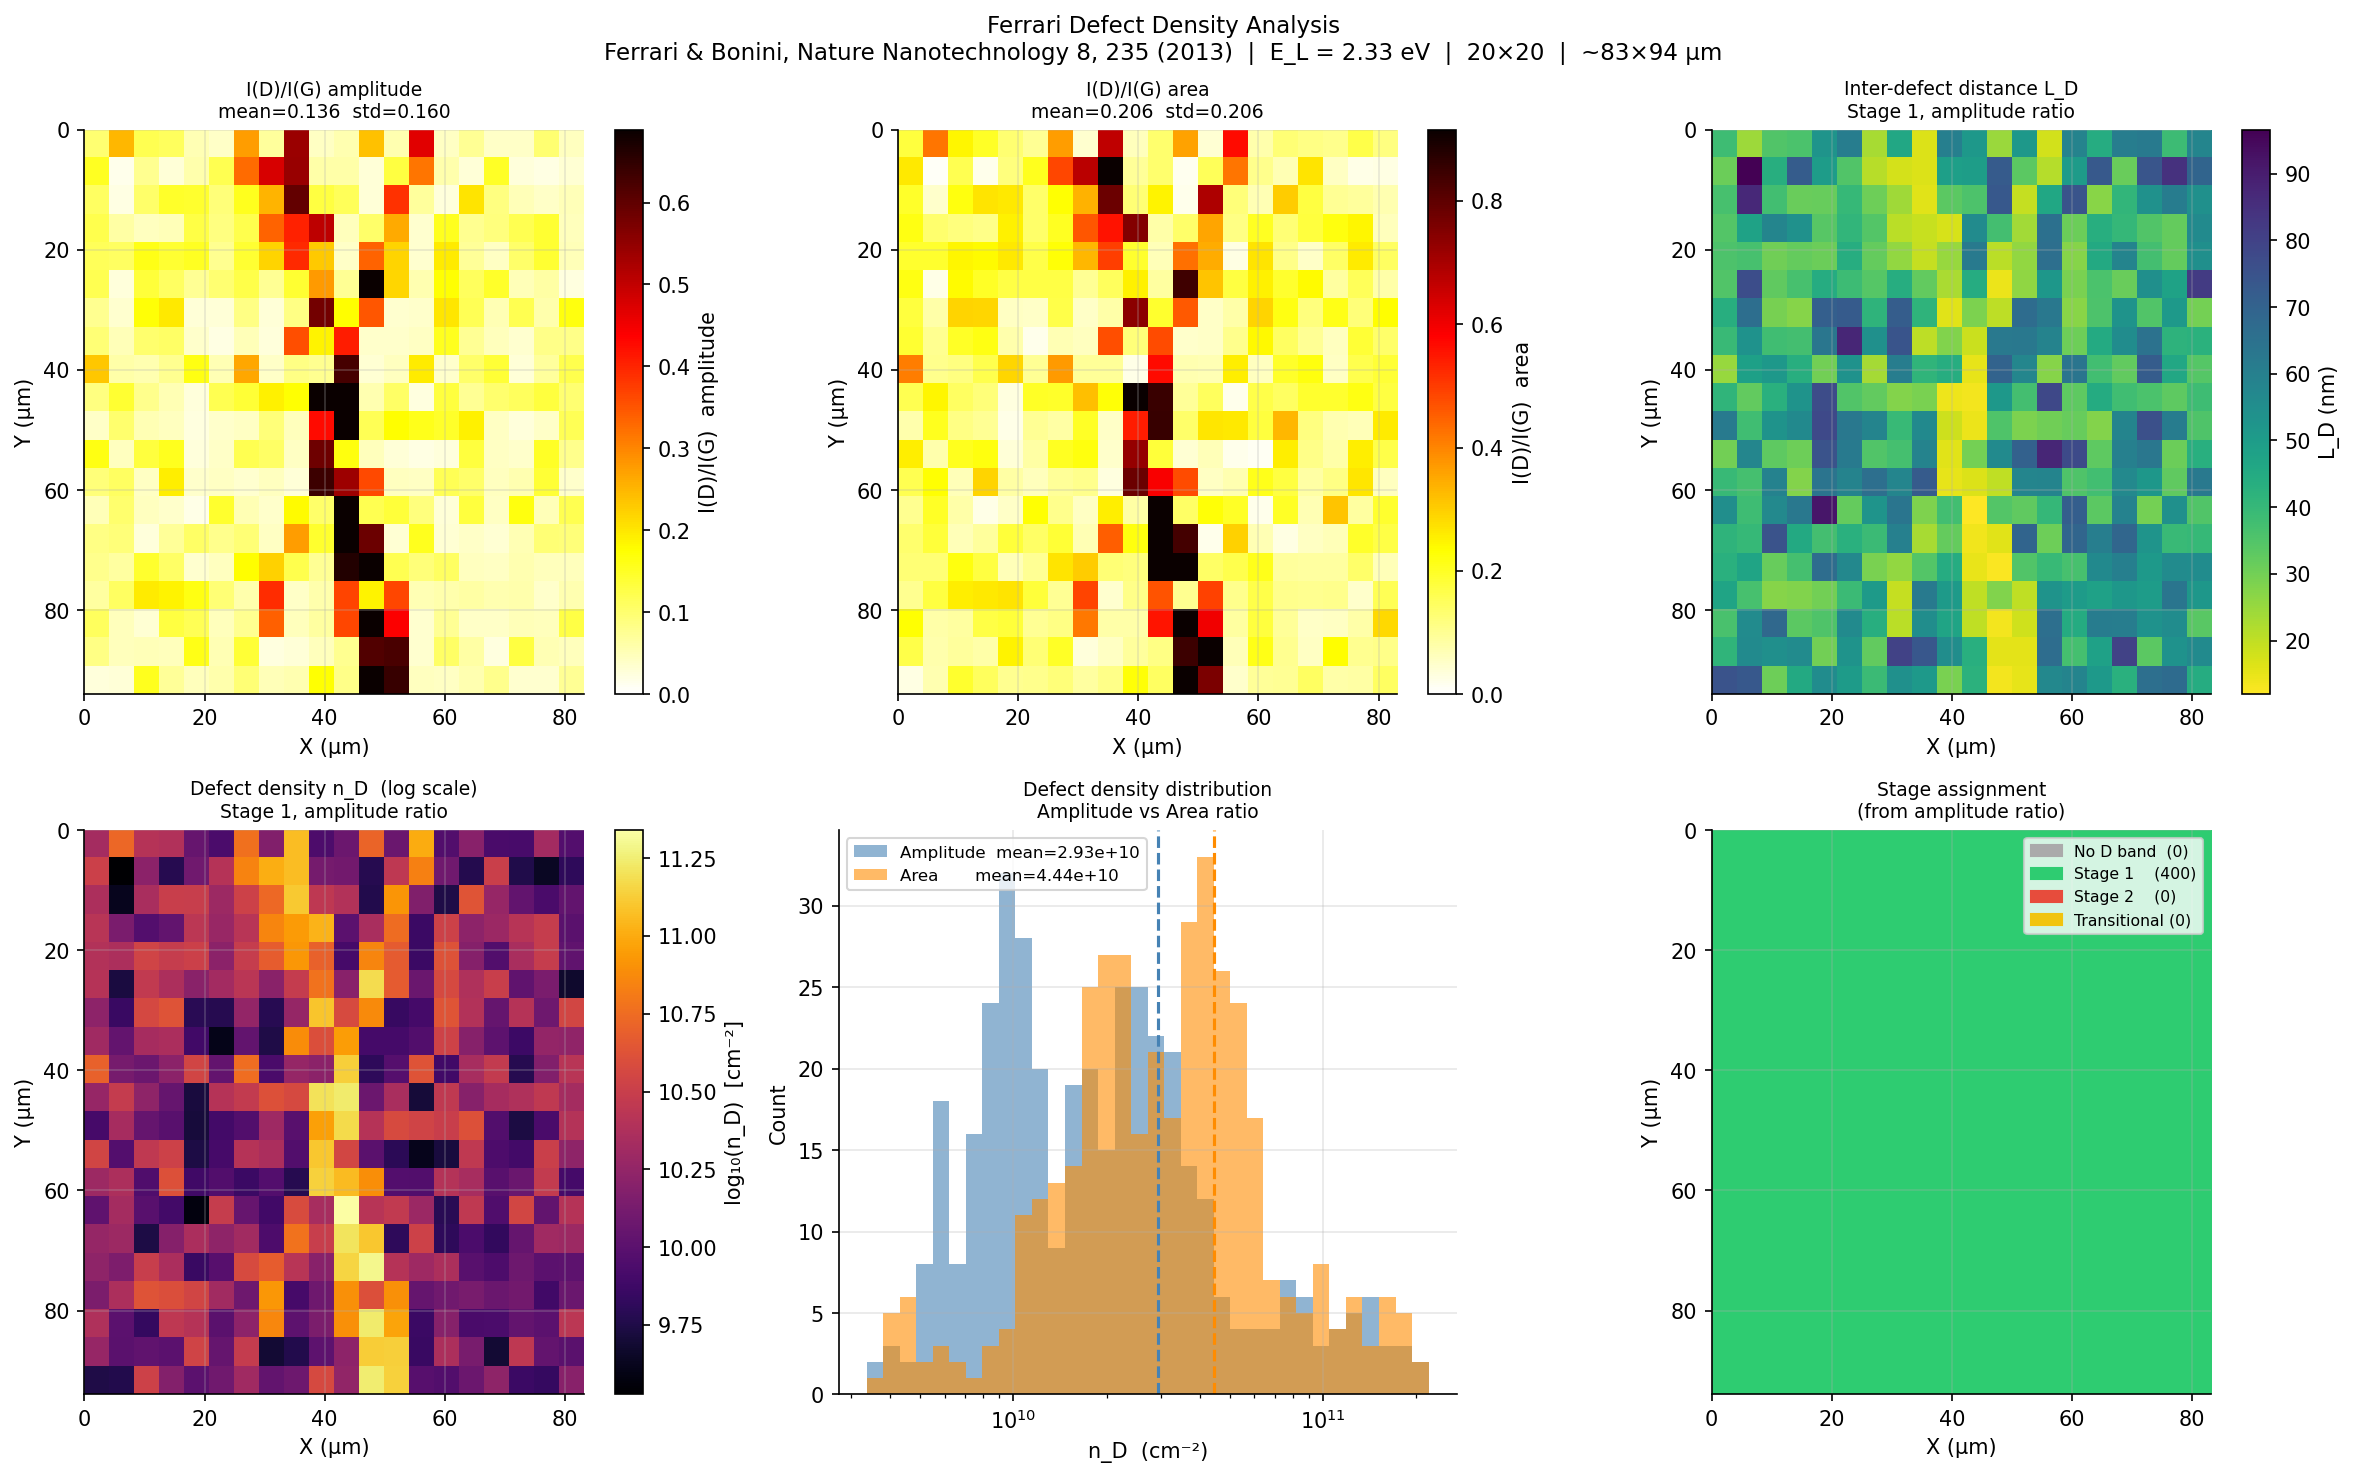

Saved: ferrari_maps.png
  ✓ Saved 14 variable(s) → ferrari_results.npz
    ['map_nD1_amp_mean', 'map_nD1_amp_std', 'map_nD1_amp_median', 'map_nD1_amp_min', 'map_nD1_amp_max', 'map_LD1_amp_mean', 'map_LD1_amp_std', 'map_nD1_area_mean', 'map_nD1_area_std', 'map_nD1_area_median', 'map_n_stage1', 'map_n_stage2', 'map_n_transitional', 'map_n_no_d']


In [6]:
# ── Cell 5: Ferrari spatial maps and distributions ────────────────────────────
# Four panels:
#   1. I(D)/I(G) amplitude map   → raw defect signal spatial distribution
#   2. LD map (Stage 1, amp)     → inter-defect distance in nm
#   3. nD map (Stage 1, amp)     → defect density in cm⁻² (log scale)
#   4. Amplitude vs area ratio   → shows how much the two conventions differ
#
# WHAT TO LOOK FOR:
#   Spatial clusters in nD map → defects at grain boundaries or folds
#   Uniform nD                 → homogeneous point defect distribution
#   Correlation with I(2D)/I(G) map → defective regions suppress 2D band
#   High nD + low LD at same pixels as low I(2D)/I(G) → self-consistent

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle(
    "Ferrari Defect Density Analysis\n"
    "Ferrari & Bonini, Nature Nanotechnology 8, 235 (2013)  |  "
    "E_L = 2.33 eV  |  20×20  |  ~83×94 µm",
    fontsize=11
)

# ── Panel 1: I(D)/I(G) amplitude map ─────────────────────────────────────────
ax = axes[0, 0]
ax.set_facecolor("#bbbbbb")
im = ax.imshow(rh.masked(rh.to_map(map_ratio_dg_amp)),
               origin="upper", extent=EXTENT,
               aspect="equal", cmap="hot_r",
               vmin=0, vmax=np.nanpercentile(map_ratio_dg_amp, 98))
plt.colorbar(im, ax=ax, fraction=0.046, label="I(D)/I(G)  amplitude")
ax.set_title(f"I(D)/I(G) amplitude\n"
             f"mean={np.nanmean(map_ratio_dg_amp):.3f}  "
             f"std={np.nanstd(map_ratio_dg_amp):.3f}", fontsize=9)
ax.set_xlabel("X (µm)"); ax.set_ylabel("Y (µm)")

# ── Panel 2: I(D)/I(G) area map ───────────────────────────────────────────────
ax = axes[0, 1]
ax.set_facecolor("#bbbbbb")
im = ax.imshow(rh.masked(rh.to_map(map_ratio_dg_area)),
               origin="upper", extent=EXTENT,
               aspect="equal", cmap="hot_r",
               vmin=0, vmax=np.nanpercentile(map_ratio_dg_area, 98))
plt.colorbar(im, ax=ax, fraction=0.046, label="I(D)/I(G)  area")
ax.set_title(f"I(D)/I(G) area\n"
             f"mean={np.nanmean(map_ratio_dg_area):.3f}  "
             f"std={np.nanstd(map_ratio_dg_area):.3f}", fontsize=9)
ax.set_xlabel("X (µm)"); ax.set_ylabel("Y (µm)")

# ── Panel 3: LD map ───────────────────────────────────────────────────────────
ax = axes[0, 2]
ax.set_facecolor("#bbbbbb")
im = ax.imshow(rh.masked(rh.to_map(map_LD1_amp)),
               origin="upper", extent=EXTENT,
               aspect="equal", cmap="viridis_r")
plt.colorbar(im, ax=ax, fraction=0.046, label="L_D (nm)")
ax.set_title(f"Inter-defect distance L_D\n"
             f"Stage 1, amplitude ratio", fontsize=9)
ax.set_xlabel("X (µm)"); ax.set_ylabel("Y (µm)")

# ── Panel 4: nD map (log scale) ───────────────────────────────────────────────
ax = axes[1, 0]
ax.set_facecolor("#bbbbbb")
log_nD = np.log10(map_nD1_amp)
im = ax.imshow(rh.masked(rh.to_map(log_nD)),
               origin="upper", extent=EXTENT,
               aspect="equal", cmap="inferno")
cb = plt.colorbar(im, ax=ax, fraction=0.046)
cb.set_label("log₁₀(n_D)  [cm⁻²]")
ax.set_title(f"Defect density n_D  (log scale)\n"
             f"Stage 1, amplitude ratio", fontsize=9)
ax.set_xlabel("X (µm)"); ax.set_ylabel("Y (µm)")

# ── Panel 5: nD histogram — amplitude vs area ─────────────────────────────────
ax = axes[1, 1]
nd_amp  = map_nD1_amp[~np.isnan(map_nD1_amp)]
nd_area = map_nD1_area[~np.isnan(map_nD1_area)]
bins    = np.logspace(np.log10(nd_amp.min()),
                      np.log10(nd_amp.max()), 35)
ax.hist(nd_amp,  bins=bins, alpha=0.6, color="steelblue",
        label=f"Amplitude  mean={nd_amp.mean():.2e}")
ax.hist(nd_area, bins=bins, alpha=0.6, color="darkorange",
        label=f"Area       mean={nd_area.mean():.2e}")
ax.set_xscale("log")
ax.set_xlabel("n_D  (cm⁻²)")
ax.set_ylabel("Count")
ax.set_title("Defect density distribution\nAmplitude vs Area ratio", fontsize=9)
ax.legend(fontsize=8)
ax.axvline(nd_amp.mean(),  color="steelblue",  lw=1.5, ls="--")
ax.axvline(nd_area.mean(), color="darkorange", lw=1.5, ls="--")

# ── Panel 6: Stage map ────────────────────────────────────────────────────────
from matplotlib.colors import ListedColormap, BoundaryNorm
import matplotlib.patches as mpatches

ax = axes[1, 2]
ax.set_facecolor("#bbbbbb")
cmap_s = ListedColormap(["#aaaaaa", "#2ecc71", "#e74c3c", "#f1c40f"])
norm_s = BoundaryNorm([-0.5, 0.5, 1.5, 2.5, 3.5], cmap_s.N)
im = ax.imshow(rh.masked(rh.to_map(map_stage.astype(float))),
               origin="upper", extent=EXTENT,
               aspect="equal", cmap=cmap_s, norm=norm_s,
               interpolation="nearest")
patches = [
    mpatches.Patch(color="#aaaaaa", label=f"No D band  ({n_no})"),
    mpatches.Patch(color="#2ecc71", label=f"Stage 1    ({n_s1})"),
    mpatches.Patch(color="#e74c3c", label=f"Stage 2    ({n_s2})"),
    mpatches.Patch(color="#f1c40f", label=f"Transitional ({n_tr})"),
]
ax.legend(handles=patches, fontsize=7.5, loc="upper right")
ax.set_title("Stage assignment\n(from amplitude ratio)", fontsize=9)
ax.set_xlabel("X (µm)"); ax.set_ylabel("Y (µm)")

plt.tight_layout()
plt.savefig("ferrari_maps.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: ferrari_maps.png")

# ── Save summary statistics ────────────────────────────────────────────────────
save_results(
    # Stage 1 amplitude
    map_nD1_amp_mean   = float(nd_amp.mean()),
    map_nD1_amp_std    = float(nd_amp.std()),
    map_nD1_amp_median = float(np.median(nd_amp)),
    map_nD1_amp_min    = float(nd_amp.min()),
    map_nD1_amp_max    = float(nd_amp.max()),
    map_LD1_amp_mean   = float(map_LD1_amp[~np.isnan(map_LD1_amp)].mean()),
    map_LD1_amp_std    = float(map_LD1_amp[~np.isnan(map_LD1_amp)].std()),
    # Stage 1 area
    map_nD1_area_mean  = float(nd_area.mean()),
    map_nD1_area_std   = float(nd_area.std()),
    map_nD1_area_median= float(np.median(nd_area)),
    # Stage counts
    map_n_stage1       = int(n_s1),
    map_n_stage2       = int(n_s2),
    map_n_transitional = int(n_tr),
    map_n_no_d         = int(n_no),
)

In [7]:
# ── Cell 6: Laser energy dependence check ─────────────────────────────────────
# Ferrari equations scale as EL⁴. For 532 nm (2.33 eV) this is locked.
# This cell shows what the defect density WOULD be at other common
# laser wavelengths — useful if you ever compare to literature values
# measured at 514 nm or 633 nm.
#
# Also computes the correction factor between amplitude and area results
# and reports the final recommended values.

EL_compare = {
    "457 nm": 2.71,
    "514 nm": 2.41,
    "532 nm": 2.33,   # ← your laser
    "633 nm": 1.96,
}

# Use the single-spectrum area ratio as the most rigorous single value
ratio_best = ratio_DG_area_ss

print(f"── EL⁴ dependence — I(D)/I(G) area = {ratio_best:.4f} ───────────────")
print(f"  {'Laser':<10} {'EL (eV)':>10} {'EL⁴':>10} "
      f"{'LD (nm)':>10} {'nD (cm⁻²)':>14}")
print(f"  {'-'*58}")
for label, el in EL_compare.items():
    ld, nd = rh.ferrari_stage1(ratio_best, 1.0, EL=el)
    marker = "  ← your laser" if el == 2.33 else ""
    print(f"  {label:<10} {el:>10.2f} {el**4:>10.4f} "
          f"{ld:>10.2f} {nd:>14.3e}{marker}")

# ── Amplitude vs area correction factor ───────────────────────────────────────
print(f"\n── Amplitude vs area correction ──────────────────────────────────────")
print(f"  fwhm_D / fwhm_G = {fwhm_D_ss:.1f} / {fwhm_G_ss:.1f} = "
      f"{fwhm_D_ss/fwhm_G_ss:.3f}")
print(f"  Area ratio / amplitude ratio = "
      f"{ratio_DG_area_ss:.4f} / {ratio_DG_amp_ss:.4f} = "
      f"{ratio_DG_area_ss/ratio_DG_amp_ss:.3f}")
print(f"  nD correction factor (area/amp) = "
      f"{ratio_DG_area_ss/ratio_DG_amp_ss:.3f}×")
print(f"  → area ratio gives "
      f"{'higher' if ratio_DG_area_ss > ratio_DG_amp_ss else 'lower'} "
      f"defect density than amplitude ratio")

# ── Final recommended values ──────────────────────────────────────────────────
LD_final, nD_final = rh.ferrari_stage1(ratio_best, 1.0, EL=EL)
LD_amp_ss, nD_amp_ss = rh.ferrari_stage1(ratio_DG_amp_ss, 1.0, EL=EL)

print(f"\n── Recommended values (single best spectrum, area ratio) ─────────────")
print(f"  I(D)/I(G) area : {ratio_best:.4f}")
print(f"  L_D            : {LD_final:.2f} nm")
print(f"  n_D            : {nD_final:.3e} cm⁻²")
print(f"  Stage          : {'Stage 1 ✓' if LD_final > 10 else 'Stage 2'}")
print(f"\n── Map-wide summary (area ratio, Stage 1) ────────────────────────────")
nd = map_nD1_area[~np.isnan(map_nD1_area)]
ld = map_LD1_area[~np.isnan(map_LD1_area)]
print(f"  n_D mean ± std : {nd.mean():.2e} ± {nd.std():.2e} cm⁻²")
print(f"  n_D median     : {np.median(nd):.2e} cm⁻²")
print(f"  L_D mean ± std : {ld.mean():.1f} ± {ld.std():.1f} nm")

# ── Save ──────────────────────────────────────────────────────────────────────
save_results(
    ss_LD_final         = float(LD_final),
    ss_nD_final         = float(nD_final),
    ss_LD_amp_final     = float(LD_amp_ss),
    ss_nD_amp_final     = float(nD_amp_ss),
    fwhm_ratio_D_over_G = float(fwhm_D_ss / fwhm_G_ss),
    area_amp_correction = float(ratio_DG_area_ss / ratio_DG_amp_ss),
)

print("\n── Ferrari analysis complete ─────────────────────────────────────────")
print(f"  All results saved to {SAVE_FILE}")

── EL⁴ dependence — I(D)/I(G) area = 0.2864 ───────────────
  Laser         EL (eV)        EL⁴    LD (nm)      nD (cm⁻²)
  ----------------------------------------------------------
  457 nm           2.71    53.9358      16.68      1.128e+11
  514 nm           2.41    33.7340      21.10      7.054e+10
  532 nm           2.33    29.4730      22.57      6.163e+10  ← your laser
  633 nm           1.96    14.7579      31.89      3.086e+10

── Amplitude vs area correction ──────────────────────────────────────
  fwhm_D / fwhm_G = 27.7 / 19.4 = 1.428
  Area ratio / amplitude ratio = 0.2864 / 0.2005 = 1.428
  nD correction factor (area/amp) = 1.428×
  → area ratio gives higher defect density than amplitude ratio

── Recommended values (single best spectrum, area ratio) ─────────────
  I(D)/I(G) area : 0.2864
  L_D            : 22.57 nm
  n_D            : 6.163e+10 cm⁻²
  Stage          : Stage 1 ✓

── Map-wide summary (area ratio, Stage 1) ────────────────────────────
  n_D mean ± std : 4.44